# C01 数据入口与可交易资产池（在线版）


In [ ]:
START_DATE = "2024-01-01"
END_DATE = "2024-12-31"
UNIVERSE = ["000001.XSHE", "000002.XSHE", "600000.XSHG", "510300.XSHG", "000300.XSHG"]
# 000001.XSHE：平安银行（深市 A 股）
# 000002.XSHE：万科A（深市 A 股）
# 600000.XSHG：浦发银行（沪市 A 股）
# 510300.XSHG：沪深300ETF（上交所 ETF）
# 000300.XSHG：沪深300指数（指数，不是单只股票）

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import rqdatac

# 把教育版 license 直接粘贴到 PASSWD
PASSWD = ""

if PASSWD:
    rqdatac.init('license', PASSWD)
    print("rqdatac 初始化成功")
else:
    print("请先填写 PASSWD，再运行本单元")


rqdatac 初始化成功


## 1) 交易数据读取
- `close`、`prev_close`、`volume`
- 使用 `adjust_type='pre'` 观察前复权口径


In [ ]:
# 读取交易数据：
# - close: 收盘价
# - prev_close: 交易所口径的“昨收”（会受分红/送转影响）
# - volume: 成交量
#
# 注意：这里用 adjust_type='pre' 是为了让 close 序列在长期上更平滑可比。
# 但 prev_close 的语义仍然是交易所发布的“昨日参考收盘价”，
# 所以它不一定等于“上一行 close”。后面我们会专门演示这一点。
px = rqdatac.get_price(
    UNIVERSE,
    start_date=START_DATE,
    end_date=END_DATE,
    fields=["close", "prev_close", "volume"],
    adjust_type="pre",
    expect_df=True,
)

# 某些返回结构是 MultiIndex（多层索引），reset_index 后更利于后续处理
price_df = px.reset_index() if isinstance(px.index, pd.MultiIndex) else px

# 先做排序，确保后续 groupby + rolling + shift 的时间顺序是正确的
price_df = price_df.sort_values(["order_book_id", "date"]).copy()
price_df.head()


,order_book_id,date,close,prev_close,volume
0,000001.XSHE,2024-01-02,7.992275,9.39,115836645.0
1,000001.XSHE,2024-01-03,7.983597,9.21,73361031.0
2,000001.XSHE,2024-01-04,7.905496,9.20,86419399.0
3,000001.XSHE,2024-01-05,8.044341,9.11,199162216.0
4,000001.XSHE,2024-01-08,7.940208,9.27,112115619.0


## 2) `prev_close` 字段详解与收益计算口径


### 2.1 `prev_close` 到底是什么（参考上一届 L02）

`prev_close` 不是简单意义上的“上一天 close 原样复制”，它是**交易所发布的昨收参考价**。

当出现以下事件时，交易所会修正“昨收参考价”：
1. 现金分红
2. 送股/转增/拆股

因此在除权除息日附近，你可能看到：
- 当天 `prev_close` != 前一行 `close`

这不是数据错，而是字段语义不同导致。


In [5]:
# 经典案例：600621 在分红附近日期
# 这里刻意使用 adjust_type='none' 看原始价格口径，便于理解 prev_close 字段语义
example = rqdatac.get_price(
    ["600621.XSHG"],
    start_date="2022-06-16",
    end_date="2022-06-17",
    fields=["prev_close", "close", "limit_up", "limit_down"],
    adjust_type="none",
    expect_df=True,
).reset_index()

example


,order_book_id,date,prev_close,close,limit_up,limit_down
0,600621.XSHG,2022-06-16,12.83,12.00,14.11,11.55
1,600621.XSHG,2022-06-17,11.86,11.78,13.05,10.67


### 2.2 两种常见收益口径

1. **交易所昨收口径**：`close / prev_close - 1`
   - 优点：贴近交易所字段定义
   - 缺点：与复权 `close` 混用时可能口径不一致

2. **前复权序列口径**（推荐用于你当前这份课件）
   - 先保证 `close` 是前复权序列
   - 再按同一序列做 `shift(1)`：`close / close.shift(1) - 1`

这样能保证收益计算前后口径一致。


In [ ]:
# ===== 收益计算：并列展示两种口径 =====

# 口径A：交易所昨收口径（直接用 prev_close）
# 含义：当天收盘价相对“交易所定义的昨收参考价”的变化
price_df["ret_prev_close"] = price_df["close"] / price_df["prev_close"] - 1

# 口径B：前复权序列口径（推荐）
# 做法：在同一个前复权 close 序列中，按资产分组后 shift(1)
# 这样保证分子分母口径一致
price_df["prev_close_pre"] = price_df.groupby("order_book_id")["close"].shift(1)
price_df["ret_pre_shift"] = price_df["close"] / price_df["prev_close_pre"] - 1

# 后续风险指标也使用 ret_pre_shift，保持一致口径
price_df["vol_20"] = (
    price_df.groupby("order_book_id")["ret_pre_shift"]
    .rolling(20)
    .std()
    .reset_index(level=0, drop=True)
)

# 比较两种口径的统计特征
ret_summary = (
    price_df.groupby("order_book_id")[["ret_prev_close", "ret_pre_shift"]]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
ret_summary


ret_prev_close                         ret_pre_shift          \
                        mean     std     min     max          mean     std   
order_book_id                                                                
000001.XSHE          -0.0913  0.0388 -0.1578 -0.0046        0.0015  0.0165   
000002.XSHE          -0.0011  0.0291 -0.1002  0.1004       -0.0010  0.0291   
000300.XSHG           0.0007  0.0135 -0.0705  0.0848        0.0007  0.0135   
510300.XSHG          -0.0471  0.0146 -0.1311  0.0429        0.0008  0.0142   
600000.XSHG          -0.0460  0.0215 -0.0870  0.0223        0.0021  0.0139   

                               
                  min     max  
order_book_id                  
000001.XSHE   -0.0932  0.0998  
000002.XSHE   -0.1002  0.1004  
000300.XSHG   -0.0705  0.0848  
510300.XSHG   -0.0884  0.0941  
600000.XSHG   -0.0562  0.0533

d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28378 (\N{CJK UNIFIED IDEOGRAPH-6EDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: User

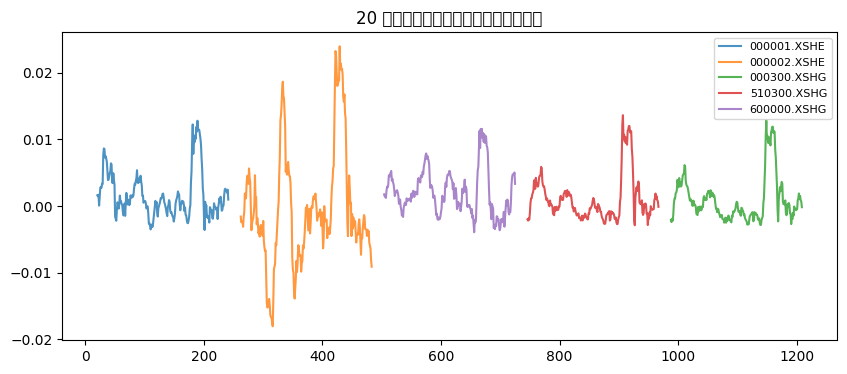

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

# 用推荐口径（ret_pre_shift）画图：
# 这是“同一前复权价格序列”下得到的收益
for asset, grp in price_df.groupby("order_book_id"):
    grp["ret_pre_shift"].rolling(20).mean().plot(ax=ax, alpha=0.8, label=asset)

ax.set_title("20 日滚动平均收益（前复权序列口径）")
ax.legend(loc="upper right", fontsize=8)
plt.show()


## 3) 可交易资产池过滤（示例）
- 过滤 ST、停牌
- 过滤低流动性


In [9]:
# 使用股票池来演示过滤逻辑
stock_list = rqdatac.all_instruments(type="stock", date=END_DATE)["order_book_id"].tolist()[:500]

st_flag = rqdatac.is_st_stock(stock_list, start_date=END_DATE, end_date=END_DATE).iloc[0]
sp_flag = rqdatac.is_suspended(stock_list, start_date=END_DATE, end_date=END_DATE).iloc[0]

candidates = [s for s in stock_list if (not st_flag.get(s, False)) and (not sp_flag.get(s, False))]

liq = rqdatac.get_price(
    candidates,
    start_date=rqdatac.get_previous_trading_date(END_DATE, 20),
    end_date=END_DATE,
    fields=["close", "volume"],
    adjust_type="pre",
    expect_df=True,
)

liq = liq.reset_index()
liq["amount"] = liq["close"] * liq["volume"]
avg_amount = liq.groupby("order_book_id")["amount"].mean().sort_values(ascending=False)
tradable_pool = avg_amount.head(100).index.tolist()

pd.Series(tradable_pool, name="tradable_pool").head(20)


0     000063.XSHE
1     000977.XSHE
2     000681.XSHE
3     000564.XSHE
4     000100.XSHE
5     000938.XSHE
6     000066.XSHE
7     000981.XSHE
8     000858.XSHE
9     000158.XSHE
10    000333.XSHE
11    000725.XSHE
12    000988.XSHE
13    000625.XSHE
14    000651.XSHE
15    000568.XSHE
16    000801.XSHE
17    000627.XSHE
18    000001.XSHE
19    000810.XSHE
Name: tradable_pool, dtype: object

## 小结
本节完全使用在线数据接口，产出 `tradable_pool` 供后续课使用。
